# **Libraries**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# **Data Dictionary**

In [2]:
pd.set_option('display.max_colwidth', None)
dictionary = pd.read_csv("ConsumerComplaints_DataDictionary.csv")
dictionary

,Field,Description
0,Complaint ID,The unique identification number for a complaint
1,Submitted via,How the complaint was submitted to the CFPB
2,Date submitted,The date the CFPB received the complaint
3,Date received,The date the CFPB sent the complaint to the company
4,State,The state of the mailing address provided by the consumer
5,Product,The type of product the consumer identified in the complaint
6,Sub-product,The type of sub-product the consumer identified in the complaint (not all Products have Sub-products)
7,Issue,The issue the consumer identified in the complaint (possible values are dependent on Product)
8,Sub-issue,"The sub-issue the consumer identified in the complaint (oossible values are dependent on Product and Issue, and not all Issues have corresponding Sub-issues)"
9,Company public response,"The company's optional, public-facing response to a consumer's complaint. Companies can choose to select a response from a pre-set list of options that will be posted on the public database. For example, ""Company believes complaint is the result of an isolated error."""


# **Exploratory Data Analysis EDA**

In [3]:
data = pd.read_excel("Consumer_Complaints.xlsx")

In [4]:
data.head(5)

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money service",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a card",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


In [5]:
data.shape

(62516, 12)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     51658 non-null  object        
 9   Company public response       60341 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

In [7]:
data.describe()

,Complaint ID,Date submitted,Date received
count,6.251600e+04,62516,62516
mean,4.512642e+06,2020-11-24 16:07:14.883869696,2020-11-25 21:31:05.071341568
min,2.471340e+06,2017-05-01 00:00:00,2017-05-01 00:00:00
25%,3.254020e+06,2019-05-22 00:00:00,2019-05-28 00:00:00
50%,4.178582e+06,2021-03-02 00:00:00,2021-03-03 00:00:00
75%,5.771284e+06,2022-07-14 00:00:00,2022-07-15 00:00:00
max,7.458912e+06,2023-08-28 00:00:00,2023-08-28 00:00:00
std,1.442917e+06,NaN,NaN


In [8]:
data.isna().sum()

,0
Complaint ID,0
Submitted via,0
Date submitted,0
Date received,0
State,0
Product,0
Sub-product,7
Issue,0
Sub-issue,10858
Company public response,2175


### **Submitted Via**

In [9]:
data['Submitted via'].value_counts()

,count
Submitted via,
Web,45423
Referral,10766
Phone,4684
Postal mail,1318
Fax,233
Web Referral,90
Email,2


## **Dates**

In [10]:
data['Date submitted'].dt.year.value_counts()

,count
Date submitted,
2022,12953
2021,11149
2023,9131
2020,8942
2018,7872
2019,7075
2017,5394


In [11]:
data['Date received'].dt.year.value_counts()

,count
Date received,
2022,12936
2021,11133
2023,9176
2020,8943
2018,7884
2019,7075
2017,5369


In [12]:
days_receive = data['Date received'] - data['Date submitted']
days_receive.sort_values(ascending=False)

,0
18384,275 days
52724,181 days
49646,179 days
57264,161 days
35899,153 days
...,...
22515,0 days
22516,0 days
22517,0 days
22518,0 days


In [13]:
month = data['Date received'].dt.month - data['Date submitted'].dt.month
month.sort_values(ascending=False)

,0
57264,6
49646,6
35899,5
23033,4
13596,4
...,...
2660,-11
2077,-11
1307,-11
1260,-11


## **State**

In [14]:
data['State'].value_counts()

,count
State,
CA,13709
FL,6488
TX,4686
NY,4442
GA,2921
NJ,2664
IL,2270
MA,2141
MD,1959


## **Product and sub Product**

In [15]:
data['Product'].value_counts()

,count
Product,
Checking or savings account,24814
Credit card or prepaid card,16197
"Credit reporting, credit repair services, or other personal consumer reports",7710
Mortgage,6601
"Money transfer, virtual currency, or money service",3453
Debt collection,2736
Vehicle loan or lease,633
"Payday loan, title loan, or personal loan",333
Student loan,39


In [16]:
data['Sub-product'].value_counts()

,count
Sub-product,
Checking account,20768
General-purpose credit card or charge card,13404
Credit reporting,7340
Conventional home mortgage,3767
Other banking product or service,2568
Government benefit card,2429
Domestic (US) money transfer,1773
Credit card debt,1697
Savings account,1239


In [17]:
data['Sub-product'].isna().sum()

np.int64(7)

In [18]:
data['Product'].isna().sum()

np.int64(0)

In [19]:
data[data["Sub-product"].isnull()]
# Checking or savings account this product has nulls (7)

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
5623,3471403,Postal mail,2019-12-18,2019-12-18,VA,Checking or savings account,NaN,Incorrect information on your report,Account status incorrect,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
14554,4301189,Web,2021-04-15,2021-04-15,FL,Checking or savings account,NaN,Problem with a credit reporting company's investigation into an existing problem,Problem with personal statement of dispute,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
39878,4406307,Web,2021-05-26,2021-06-03,CA,Checking or savings account,NaN,Incorrect information on your report,Personal information incorrect,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
40582,2998085,Web,2018-08-21,2018-08-21,MA,Checking or savings account,NaN,Problem with a credit reporting company's investigation into an existing problem,Was not notified of investigation status or results,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
42790,4307513,Web,2021-04-18,2021-04-19,NY,Checking or savings account,NaN,Incorrect information on your report,Account status incorrect,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with non-monetary relief,Yes
55010,3210750,Web,2019-04-12,2019-04-12,FL,Checking or savings account,NaN,Incorrect information on your report,Information belongs to someone else,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62288,5584888,Web,2022-05-20,2022-05-20,KY,Checking or savings account,NaN,Incorrect information on your report,Information belongs to someone else,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes


In [20]:
pd.set_option('display.max_rows',15)
data[data["Product"] =='Checking or savings account']

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
6,4348292,Web,2021-05-04,2021-05-04,TX,Checking or savings account,Checking account,Closing an account,Funds not received from closed account,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
9,6203657,Web,2022-11-14,2022-11-14,VA,Checking or savings account,Other banking product or service,Closing an account,Funds not received from closed account,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
11,5336959,Web,2022-03-18,2022-03-18,KS,Checking or savings account,Checking account,Opening an account,Account opened as a result of fraud,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
12,5618881,Web,2022-05-28,2022-05-28,GA,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
14,5618923,Web,2022-05-28,2022-05-28,CA,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
62506,5817092,Phone,2022-07-27,2022-07-27,IL,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62507,6475744,Web,2023-01-23,2023-01-23,NY,Checking or savings account,Other banking product or service,Managing an account,Problem accessing account,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62510,5204472,Postal mail,2022-02-09,2022-02-09,MA,Checking or savings account,Checking account,Managing an account,Problem accessing account,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
62511,2501211,Web,2017-06-04,2017-06-04,TX,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


### **Solve Missing values**

In [21]:
data["Sub-product"] = data["Sub-product"].fillna("Not Specified")

## **Issue and Sub issue**

In [22]:
data['Issue'].value_counts()

,count
Issue,
Managing an account,15109
Incorrect information on your report,4931
Problem with a purchase shown on your statement,4415
Closing an account,2953
Trouble during payment process,2827
...,...
Getting a loan,2
"Was approved for a loan, but didn't receive money",1
Vehicle was damaged or destroyed the vehicle,1


In [23]:
data['Issue'].isna().sum()

np.int64(0)

In [24]:
data['Sub-issue'].value_counts()

,count
Sub-issue,
Deposits and withdrawals,5596
Problem using a debit or ATM card,3356
Credit card company isn't resolving a dispute about a purchase on your statement,2770
Information belongs to someone else,2401
Company closed your account,2312
...,...
"Was signed up for overdraft on card, but don't want to be",1
Threatened to turn you in to immigration or deport you,1
Can't temporarily delay making payments,1


In [25]:
data['Sub-issue'].isna().sum()

np.int64(10858)

In [26]:
pd.set_option('display.max_rows',15)
data[data['Sub-issue'].isna()]

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money service",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
10,5092497,Web,2022-01-10,2022-01-10,FL,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
13,2850455,Web,2018-03-21,2018-03-21,FL,"Money transfer, virtual currency, or money service",International money transfer,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
15,7230934,Web,2023-07-10,2023-07-10,FL,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
62498,2489315,Web,2017-05-19,2017-05-19,CA,Mortgage,Other type of mortgage,Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62509,6157631,Referral,2022-11-01,2022-11-02,WI,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62513,3704015,Web,2020-06-17,2020-06-17,TN,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62514,2488973,Referral,2017-05-19,2017-05-19,GA,Mortgage,Other type of mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


In [27]:
data[data['Issue'] == 'Applying for a mortgage or refinancing an existing mortgage']

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
10,5092497,Web,2022-01-10,2022-01-10,FL,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
15,7230934,Web,2023-07-10,2023-07-10,FL,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
194,3225742,Web,2019-04-29,2019-04-30,CA,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
266,3276143,Referral,2019-06-14,2019-06-15,MI,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
62257,5888437,Web,2022-08-17,2022-08-17,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62289,2503441,Referral,2017-06-06,2017-06-07,MD,Mortgage,Other type of mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62363,3716429,Web,2020-06-25,2020-06-25,AZ,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62479,5402096,Web,2022-04-04,2022-04-04,WA,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


In [28]:
data['Sub-issue'][data['Issue'] == 'Applying for a mortgage or refinancing an existing mortgage']

,Sub-issue
0,NaN
10,NaN
15,NaN
194,NaN
266,NaN
...,...
62257,NaN
62289,NaN
62363,NaN
62479,NaN


In [29]:
data['Sub-issue'][data['Issue'] == 'Applying for a mortgage or refinancing an existing mortgage'].isna().sum()

# This issue doesn't have a sub issue

np.int64(1017)

In [30]:
data[data['Issue'] == 'Lost or stolen check']

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money service",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
643,5541160,Web,2022-05-04,2022-05-04,CT,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,No
1419,5059652,Web,2021-12-31,2021-12-31,FL,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
2396,6068722,Web,2022-10-10,2022-10-10,NV,"Money transfer, virtual currency, or money service",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
3372,5063815,Phone,2022-01-03,2022-01-03,NY,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
54469,5641087,Web,2022-06-07,2022-06-07,CA,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with non-monetary relief,Yes
55386,6210015,Web,2022-11-17,2022-11-17,NC,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
57912,3702390,Web,2020-06-17,2020-06-17,IL,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
61626,3685618,Web,2020-06-05,2020-06-05,VA,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


In [31]:
data['Sub-issue'][data['Issue'] == 'Lost or stolen check']

,Sub-issue
1,NaN
643,NaN
1419,NaN
2396,NaN
3372,NaN
...,...
54469,NaN
55386,NaN
57912,NaN
61626,NaN


In [32]:
data['Sub-issue'][data['Issue'] == 'Lost or stolen check'].isna().sum()

# This issue doesn't have a sub issue

np.int64(50)

In [33]:
data[data['Issue'] == 'Fraud or scam']

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
13,2850455,Web,2018-03-21,2018-03-21,FL,"Money transfer, virtual currency, or money service",International money transfer,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
38,5736591,Web,2022-07-05,2022-07-05,NY,"Money transfer, virtual currency, or money service",International money transfer,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
51,3593281,Web,2020-04-04,2020-04-04,PA,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
116,5685678,Web,2022-06-19,2022-06-19,FL,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
135,5950079,Web,2022-09-06,2022-09-06,MD,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
62475,5604791,Web,2022-05-26,2022-05-26,OR,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62478,6215912,Web,2022-11-17,2022-11-17,CA,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62482,5885216,Web,2022-08-16,2022-08-16,TX,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62485,4275351,Phone,2021-04-06,2021-04-06,MA,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


In [34]:
data['Sub-issue'][data['Issue'] == 'Fraud or scam']

,Sub-issue
13,NaN
38,NaN
51,NaN
116,NaN
135,NaN
...,...
62475,NaN
62478,NaN
62482,NaN
62485,NaN


In [35]:
data['Sub-issue'][data['Issue'] == 'Fraud or scam'].isna().sum()

# This issue doesn't have a sub issue

np.int64(1987)

In [36]:
data[data['Issue'] == 'Closing on a mortgage']

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
193,3401524,Web,2019-10-10,2019-10-10,NM,Mortgage,Conventional home mortgage,Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
215,3934785,Web,2020-11-03,2020-11-03,FL,Mortgage,Home equity loan or line of credit (HELOC),Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
311,2732165,Phone,2017-11-17,2017-11-21,FL,Mortgage,Home equity loan or line of credit (HELOC),Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
811,2578885,Web,2017-07-19,2017-07-19,OR,Mortgage,FHA mortgage,Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
1032,3817358,Web,2020-08-27,2020-08-27,WA,Mortgage,Conventional home mortgage,Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
62029,4562158,Web,2021-07-21,2021-07-21,MA,Mortgage,Conventional home mortgage,Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with non-monetary relief,Yes
62121,3859947,Referral,2020-09-19,2020-09-22,NY,Mortgage,Home equity loan or line of credit (HELOC),Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62328,2816092,Web,2018-02-16,2018-02-16,NC,Mortgage,Other type of mortgage,Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62376,2745481,Web,2017-12-05,2017-12-05,CA,Mortgage,Conventional home mortgage,Closing on a mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


In [37]:
data['Sub-issue'][data['Issue'] == 'Closing on a mortgage']

,Sub-issue
193,NaN
215,NaN
311,NaN
811,NaN
1032,NaN
...,...
62029,NaN
62121,NaN
62328,NaN
62376,NaN


In [38]:
data['Sub-issue'][data['Issue'] == 'Closing on a mortgage'].isna().sum()

np.int64(609)

In [39]:
data[data['Issue'] == 'Confusing or missing disclosures']

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
102,6190474,Web,2022-11-11,2022-11-11,NY,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
2517,7422601,Web,2023-08-18,2023-08-18,KS,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Confusing or missing disclosures,NaN,NaN,In progress,NaN
2669,5325289,Web,2022-03-15,2022-03-15,CA,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
4879,6431780,Web,2023-01-12,2023-01-12,VA,"Money transfer, virtual currency, or money service",Foreign currency exchange,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
5362,5600494,Phone,2022-05-25,2022-05-25,PA,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
58851,3327754,Web,2019-08-02,2019-08-02,TN,"Money transfer, virtual currency, or money service",Traveler's check or cashier's check,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
60080,4804133,Web,2021-10-13,2021-10-13,PA,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with non-monetary relief,Yes
61430,2755863,Web,2017-12-14,2017-12-14,AL,"Money transfer, virtual currency, or money service",International money transfer,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62465,6031540,Web,2022-09-29,2022-10-05,NJ,"Money transfer, virtual currency, or money service",Money order,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


In [40]:
data['Sub-issue'][data['Issue'] == 'Confusing or missing disclosures']

,Sub-issue
102,NaN
2517,NaN
2669,NaN
4879,NaN
5362,NaN
...,...
58851,NaN
60080,NaN
61430,NaN
62465,NaN


In [41]:
data['Sub-issue'][data['Issue'] == 'Confusing or missing disclosures'].isna().sum()
# This issue doesn't have a sub issue

np.int64(87)

In [42]:
data[data['Issue']== 'Trouble during payment process']

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
34,3845288,Web,2020-09-11,2020-09-11,IN,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
57,5235763,Referral,2022-02-15,2022-02-17,MI,Mortgage,Home equity loan or line of credit (HELOC),Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with non-monetary relief,Yes
84,4291119,Referral,2021-04-08,2021-04-12,FL,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
90,3297138,Web,2019-07-05,2019-07-05,TX,Mortgage,FHA mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
92,6964251,Web,2023-05-11,2023-05-12,GA,Mortgage,FHA mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
62452,4210856,Web,2021-03-13,2021-03-13,PA,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with non-monetary relief,Yes
62456,2488220,Referral,2017-05-18,2017-05-18,NJ,Mortgage,Other type of mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62467,2497496,Referral,2017-05-26,2017-05-30,VA,Mortgage,Other type of mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62509,6157631,Referral,2022-11-01,2022-11-02,WI,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


In [43]:
data['Sub-issue'][data['Issue']== 'Trouble during payment process']

,Sub-issue
34,NaN
57,NaN
84,NaN
90,NaN
92,NaN
...,...
62452,NaN
62456,NaN
62467,NaN
62509,NaN


In [44]:
data['Sub-issue'][data['Issue']== 'Trouble during payment process'].isna().sum()

 # This issue doesn't have a sub issue

np.int64(2827)

### **Solve Missing values**

In [45]:
data.loc[(data['Issue'] == 'Closing on a mortgage') & (data['Sub-issue'].isna()),'Sub-issue'] = 'Closing disclosure or other related disclosures'

In [46]:
data['Sub-issue'] = data['Sub-issue'].fillna('Not specified')

## **Company response to consumer**


In [47]:
data['Company response to consumer'].value_counts()

,count
Company response to consumer,
Closed with explanation,41044
Closed with monetary relief,14697
Closed with non-monetary relief,5273
In progress,1494
Closed,8


In [48]:
data['Company response to consumer'].isna().sum()

np.int64(0)

## **Company public response**

In [49]:
data['Company public response'].value_counts()

,count
Company public response,
Company has responded to the consumer and the CFPB and chooses not to provide a public response,60311
Company believes the complaint provided an opportunity to answer consumer's questions,12
Company believes the complaint is the result of a misunderstanding,7
Company believes it acted appropriately as authorized by contract or law,6
Company believes complaint caused principally by actions of third party outside the control or direction of the company,3
Company disputes the facts presented in the complaint,2


In [50]:
data['Company public response'].isna().sum()

np.int64(2175)

In [51]:
pd.crosstab(data['Company public response'].isna(), data['Timely response?'])

Timely response?,No,Yes
Company public response,,
False,2217,58124
True,186,495


### **Solve Missing values**

In [52]:
data['Company public response'] = data['Company public response'].fillna(data['Company public response'].mode()[0])

## T**imely response**

In [53]:
data['Timely response?'].value_counts()

,count
Timely response?,
Yes,58619
No,2403


In [54]:
data['Timely response?'].isna().sum()

np.int64(1494)

In [55]:
data['Date received'][data['Timely response?'].isna()]

,Date received
3,2023-07-11
69,2023-08-11
94,2023-08-11
105,2023-08-11
145,2023-07-28
...,...
58664,2023-07-03
58705,2023-06-27
58780,2023-07-05
58795,2023-07-17


### **Solve Missing values**

In [56]:
data['Timely response?'] = data['Timely response?'].fillna('No response recorded')

In [57]:
data.isna().sum()

,0
Complaint ID,0
Submitted via,0
Date submitted,0
Date received,0
State,0
Product,0
Sub-product,0
Issue,0
Sub-issue,0
Company public response,0


# **New Columns**

## **state Name column**

In [58]:
state_map = {
    'NY': 'New York',
    'FL': 'Florida',
    'CA': 'California',
    'VA': 'Virginia',
    'TX': 'Texas',
    'KS': 'Kansas',
    'GA': 'Georgia',
    'CT': 'Connecticut',
    'OH': 'Ohio',
    'NJ': 'New Jersey',
    'IL': 'Illinois',
    'MI': 'Michigan',
    'NC': 'North Carolina',
    'PA': 'Pennsylvania',
    'WA': 'Washington',
    'IN': 'Indiana',
    'MA': 'Massachusetts',
    'MD': 'Maryland',
    'NV': 'Nevada',
    'TN': 'Tennessee',
    'AZ': 'Arizona',
    'MO': 'Missouri',
    'DC': 'District of Columbia',
    'ID': 'Idaho',
    'MS': 'Mississippi',
    'CO': 'Colorado',
    'OR': 'Oregon',
    'MN': 'Minnesota',
    'KY': 'Kentucky',
    'AR': 'Arkansas',
    'NH': 'New Hampshire',
    'NM': 'New Mexico',
    'UT': 'Utah',
    'SC': 'South Carolina',
    'AL': 'Alabama',
    'DE': 'Delaware',
    'OK': 'Oklahoma',
    'LA': 'Louisiana',
    'RI': 'Rhode Island',
    'WI': 'Wisconsin',
    'IA': 'Iowa',
    'ME': 'Maine',
    'WV': 'West Virginia',
    'VT': 'Vermont',
    'NE': 'Nebraska',
    'SD': 'South Dakota',
    'HI': 'Hawaii',
    'AK': 'Alaska',
    'MT': 'Montana',
    'ND': 'North Dakota',
    'WY': 'Wyoming'
}

In [59]:
data["State name"] = data["State"].map(state_map)

## **Year columns**

In [60]:
data["Received Year"] = data["Date received"].dt.year
data["Submitted Year"] = data["Date submitted"].dt.year

## **Days to receive column**

In [61]:
data["Days_to_receive"] = (data["Date received"] - data["Date submitted"]).dt.days

# **Analyze data**

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62516 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     62516 non-null  object        
 9   Company public response       62516 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

## **Overview**

In [63]:
# number of complaints
number_of_complaints = data['Complaint ID'].count()
number_of_complaints

np.int64(62516)

In [64]:
 # Average days to receive complaints
avg_days = np.ceil(data['Days_to_receive'].mean())
avg_days

np.float64(2.0)

In [65]:
# number of complaints between Submitted Year and Receive Year
submitted_counts = data['Submitted Year'].value_counts().sort_index()
received_counts = data['Received Year'].value_counts().sort_index()
year_diff = submitted_counts.to_frame('Submitted').join(received_counts.to_frame('Received'), how='outer')
year_diff

,Submitted,Received
Submitted Year,,
2017,5394,5369
2018,7872,7884
2019,7075,7075
2020,8942,8943
2021,11149,11133
2022,12953,12936
2023,9131,9176


In [66]:
# Number of Products
unique_product = pd.DataFrame(data['Product'].unique(),columns=['products'])
print(unique_product,'\n',"#products: ",len(unique_product))


                                                                       products
0                                                                      Mortgage
1                            Money transfer, virtual currency, or money service
2  Credit reporting, credit repair services, or other personal consumer reports
3                                                   Credit card or prepaid card
4                                                   Checking or savings account
5                                                         Vehicle loan or lease
6                                                               Debt collection
7                                     Payday loan, title loan, or personal loan
8                                                                  Student loan 
 #products:  9


In [67]:
# Number of complaints which response on time
timely_response = data['Timely response?'].value_counts()
timely_response


,count
Timely response?,
Yes,58619
No,2403
No response recorded,1494


## **Submission**


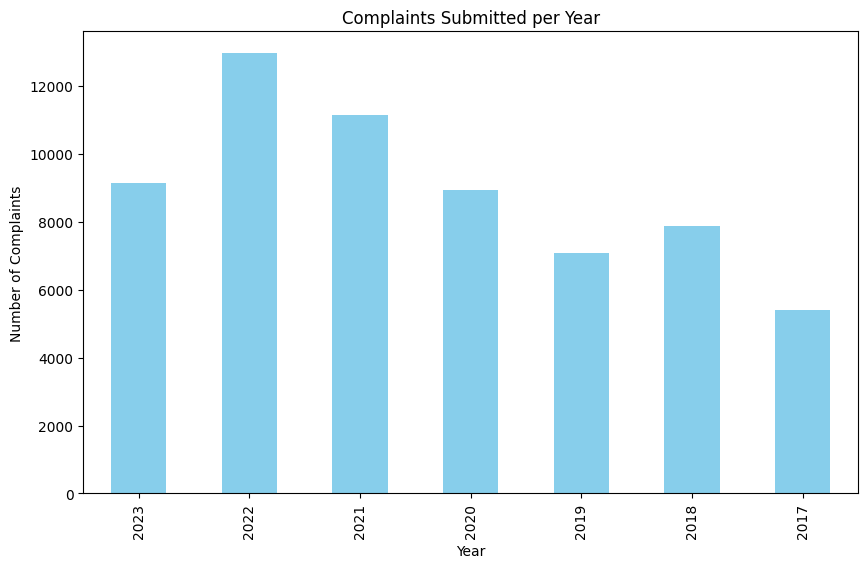

In [68]:
# number of complaints per year

year_counts = data['Submitted Year'].value_counts().sort_index(ascending=False)
year_counts.plot(kind='bar', figsize=(10,6), color='skyblue')
plt.xlabel('Year')
plt.ylabel('Number of Complaints')
plt.title('Complaints Submitted per Year')
plt.show()

/tmp/ipykernel_6920/1884940198.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.countplot(data=data, x="Submitted via",order=order, palette="pastel")


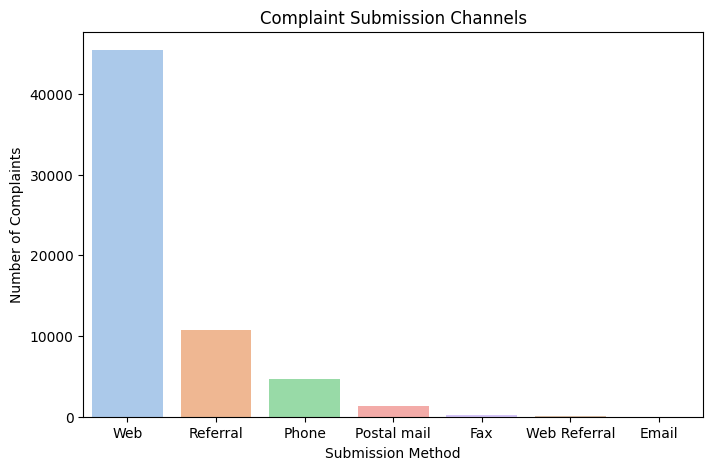

In [69]:
# most common channels used to submit complaints and submission channels that are rarely used

plt.figure(figsize=(8,5))
order = data['Submitted via'].value_counts().index
sn.countplot(data=data, x="Submitted via",order=order, palette="pastel")
plt.title("Complaint Submission Channels")
plt.xlabel("Submission Method")
plt.ylabel("Number of Complaints")

plt.show()

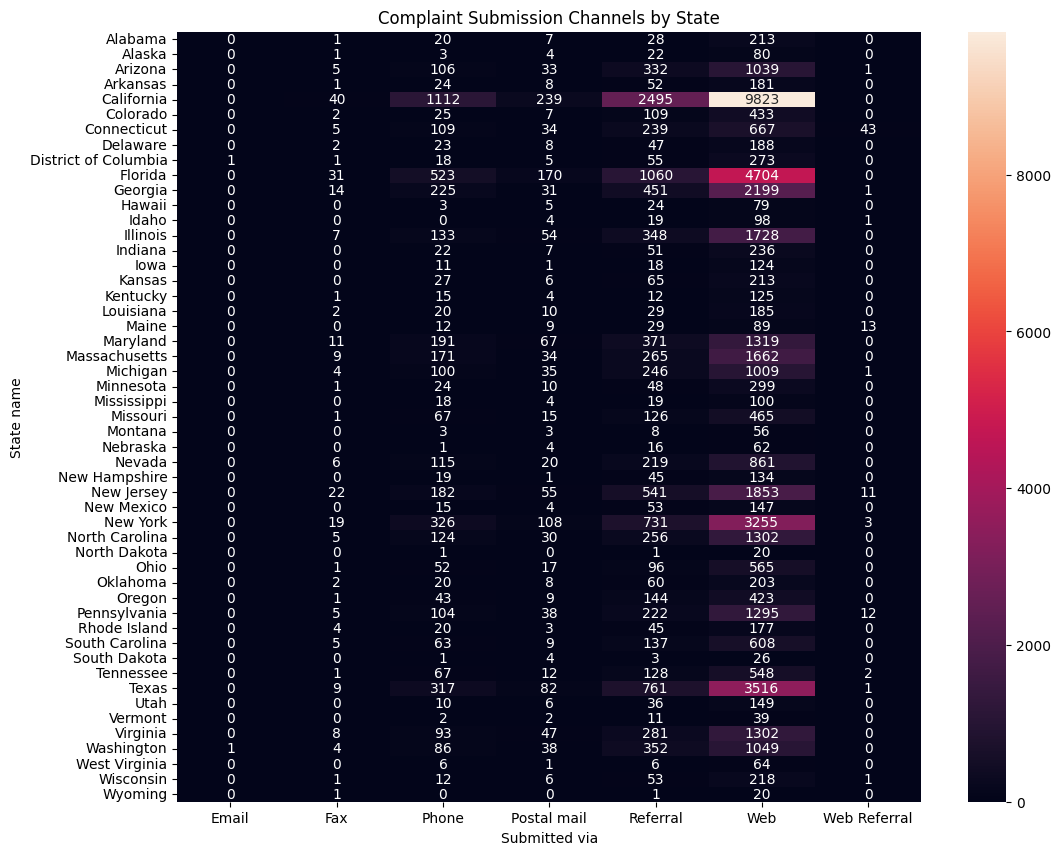

In [70]:
# submission channels are most popular in each state

pivot = data.pivot_table(index='State name', columns='Submitted via', aggfunc='size', fill_value=0)
colors = sn.color_palette("pastel")
plt.figure(figsize=(12,10))
sn.heatmap(pivot, cmap=sn.color_palette("rocket", as_cmap=True), annot=True, fmt="d")
plt.title("Complaint Submission Channels by State")
plt.show()

In [71]:
# submission channel receives the highest number of complaints per year
year_channel_counts = data.groupby(['Submitted Year', 'Submitted via']).size().reset_index(name='Count')
year_channel_counts

,Submitted Year,Submitted via,Count
0,2017,Fax,62
1,2017,Phone,283
2,2017,Postal mail,281
3,2017,Referral,1284
4,2017,Web,3484
...,...,...,...
32,2023,Phone,776
33,2023,Postal mail,76
34,2023,Referral,315
35,2023,Web,7916


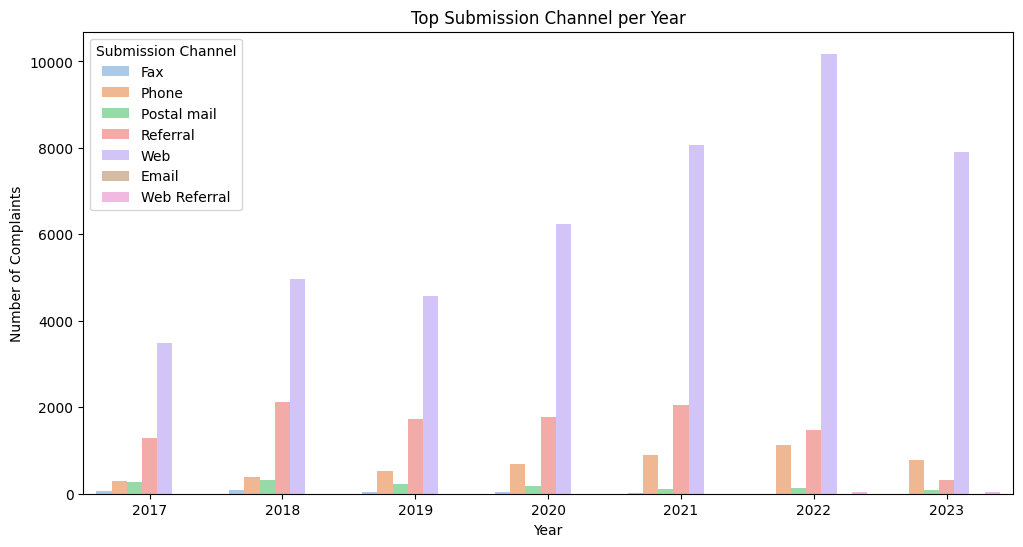

In [72]:
plt.figure(figsize=(12,6))
sn.barplot(
    data=year_channel_counts,
    x='Submitted Year',
    y='Count',
    hue='Submitted via',
    palette='pastel'
)
plt.title("Top Submission Channel per Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.legend(title="Submission Channel")
plt.show()

## **Receiving**

/tmp/ipykernel_6920/213358848.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(data=avg_days, x='Submitted via', y='Days_to_receive', palette='pastel')


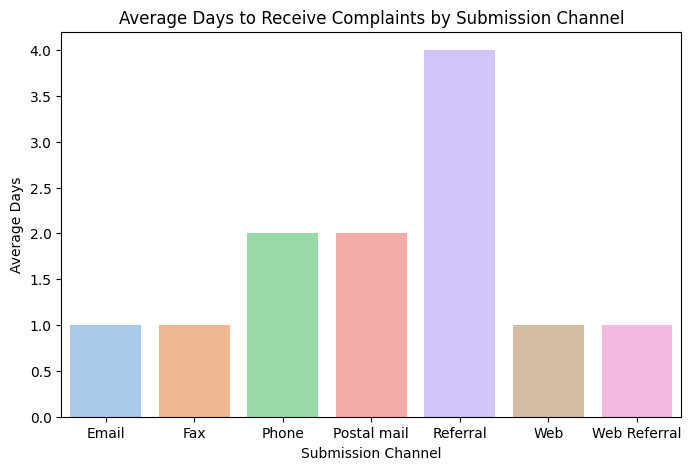

In [73]:
# Average days to Receive Complaints per submission channel

avg_days = np.ceil(data.groupby('Submitted via')['Days_to_receive'].mean()).reset_index()

plt.figure(figsize=(8,5))
sn.barplot(data=avg_days, x='Submitted via', y='Days_to_receive', palette='pastel')
plt.title("Average Days to Receive Complaints by Submission Channel")
plt.xlabel("Submission Channel")
plt.ylabel("Average Days")
plt.show()

/tmp/ipykernel_6920/2162841782.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(data=complaints_by_year, x='Receive Year', y='Count', palette='pastel')


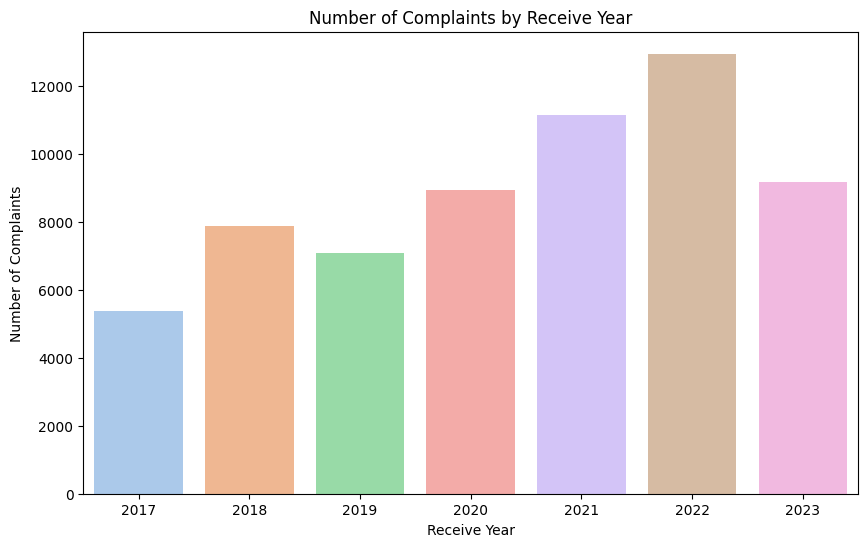

In [74]:
# Number of Complaints by Receive Year
complaints_by_year = data['Received Year'].value_counts().sort_index().reset_index()
complaints_by_year.columns = ['Receive Year', 'Count']

plt.figure(figsize=(10,6))
sn.barplot(data=complaints_by_year, x='Receive Year', y='Count', palette='pastel')
plt.title("Number of Complaints by Receive Year")
plt.xlabel("Receive Year")
plt.ylabel("Number of Complaints")
plt.show()

## **States**

In [75]:
# states have the highest number of complaints
states = data['State name'].value_counts()
top_states = states.head(10)
top_states

,count
State name,
California,13709
Florida,6488
Texas,4686
New York,4442
Georgia,2921
New Jersey,2664
Illinois,2270
Massachusetts,2141
Maryland,1959


/tmp/ipykernel_6920/3313522451.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(x=top_states.values, y=top_states.index, palette='pastel')


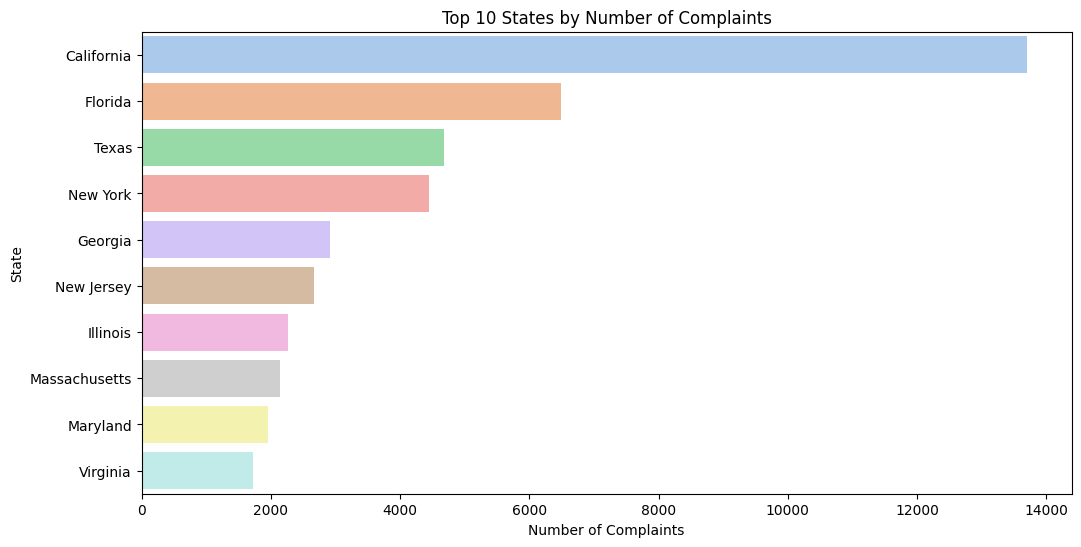

In [76]:
plt.figure(figsize=(12,6))
sn.barplot(x=top_states.values, y=top_states.index, palette='pastel')
plt.title("Top 10 States by Number of Complaints")
plt.xlabel("Number of Complaints")
plt.ylabel("State")
plt.show()

/tmp/ipykernel_6920/2352694094.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(data=top_states, x='State name', y='Days_to_receive', palette='pastel')


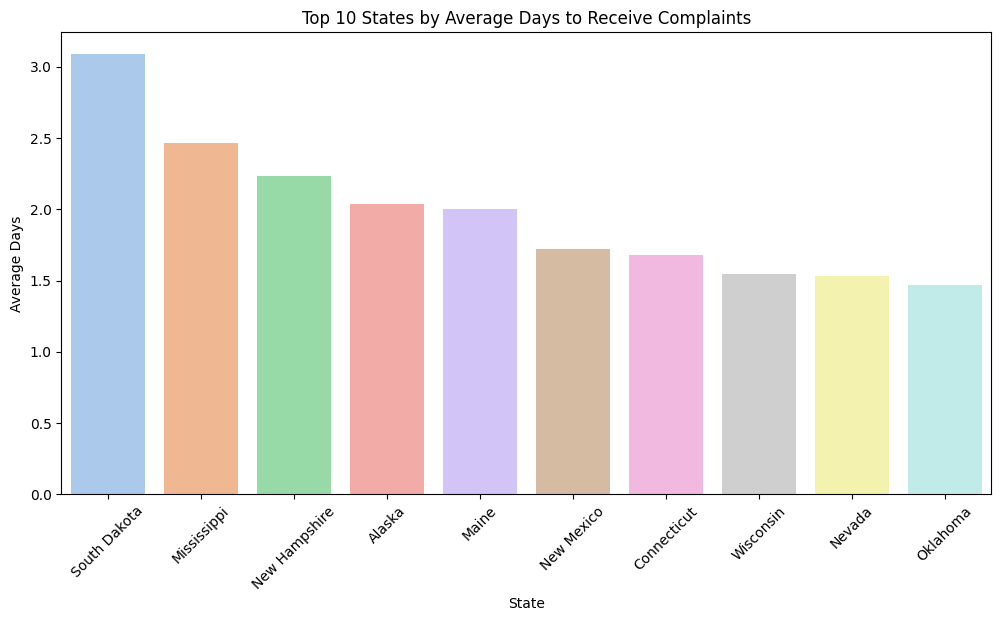

In [77]:
 # Average days per Top 10 states
avg_days = data.groupby('State name')['Days_to_receive'].mean().reset_index()
top_states = avg_days.sort_values('Days_to_receive', ascending=False).head(10)

plt.figure(figsize=(12,6))
sn.barplot(data=top_states, x='State name', y='Days_to_receive', palette='pastel')
plt.title("Top 10 States by Average Days to Receive Complaints")
plt.xlabel("State")
plt.ylabel("Average Days")
plt.xticks(rotation=45)
plt.show()

In [78]:
# product has the most complaints in each state
state_product_counts = data.groupby(['State name', 'Product']).size().reset_index(name='Count')
top_product_state = state_product_counts.loc[state_product_counts.groupby('State name')['Count'].idxmax()]
top_product_state

,State name,Product,Count
1,Alabama,Credit card or prepaid card,78
10,Alaska,Credit card or prepaid card,60
15,Arizona,Checking or savings account,633
24,Arkansas,Checking or savings account,118
32,California,Checking or savings account,5335
...,...,...,...
366,Virginia,Checking or savings account,667
375,Washington,Credit card or prepaid card,556
383,West Virginia,Checking or savings account,32
390,Wisconsin,Credit card or prepaid card,134


## **Products and Sub products**

In [79]:
# Number of complaints per product
count_product = data['Product'].value_counts()
count_product

,count
Product,
Checking or savings account,24814
Credit card or prepaid card,16197
"Credit reporting, credit repair services, or other personal consumer reports",7710
Mortgage,6601
"Money transfer, virtual currency, or money service",3453
Debt collection,2736
Vehicle loan or lease,633
"Payday loan, title loan, or personal loan",333
Student loan,39


/tmp/ipykernel_6920/1927791381.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(x=count_product.values, y=count_product.index, palette='pastel')


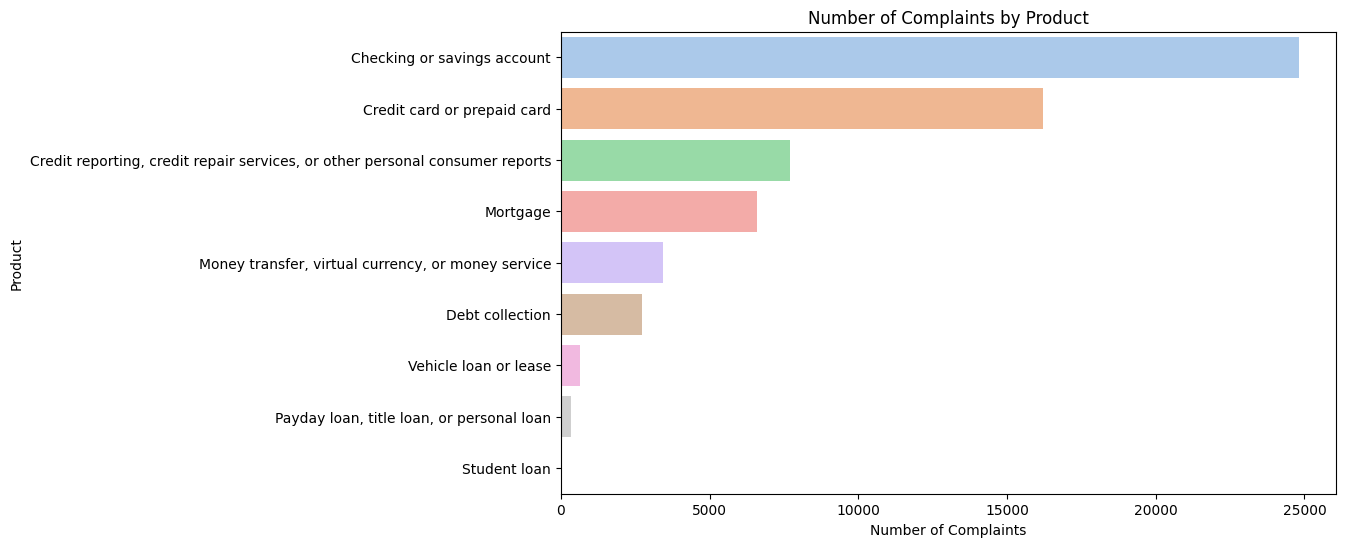

In [80]:
plt.figure(figsize=(10,6))
sn.barplot(x=count_product.values, y=count_product.index, palette='pastel')
plt.title("Number of Complaints by Product")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.show()

In [81]:
# number of complaints in each sub product
pd.set_option('display.max_rows', None)
sub_product_counts = data.groupby('Product')['Sub-product'].value_counts()
sub_product_counts

Product                                                                       Sub-product                               
Checking or savings account                                                   Checking account                              20768
                                                                              Other banking product or service               2568
                                                                              Savings account                                1239
                                                                              CD (Certificate of Deposit)                     232
                                                                              Not Specified                                     7
Credit card or prepaid card                                                   General-purpose credit card or charge card    13404
                                                                              Government benefit card                        2429
                                                                              General-purpose prepaid card                    260
                                                                              Store credit card                                52
                                                                              Payroll card                                     40
                                                                              Gift card                                        12
Credit reporting, credit repair services, or other personal consumer reports  Credit reporting                               7340
                                                                              Other personal consumer report                  299
                                                                              Credit repair services                           71
Debt collection                                                               Credit card debt                               1697
                                                                              Mortgage debt                                   341
                                                                              I do not know                                   314
                                                                              Other debt                                      282
                                                                              Auto debt                                        65
                                                                              Private student loan debt                        17
                                                                              Federal student loan debt                         9
                                                                              Payday loan debt                                  8
                                                                              Medical debt                                      3
Money transfer, virtual currency, or money service                            Domestic (US) money transfer                   1773
                                                                              Mobile or digital wallet                        655
                                                                              International money transfer                    411
                                                                              Virtual currency                                208
                                                                              Traveler's check or cashier's check             149
                                                                              Check cashing service                           102
                                                                              Refund anticipation check      

In [82]:
# the product with the most complaints in each year
product_year_counts = data.groupby(['Product', 'Submitted Year']).size().reset_index(name='Count')
top_product_year = product_year_counts.loc[product_year_counts.groupby('Submitted Year')['Count'].idxmax()]

top_product_year

,Product,Submitted Year,Count
0,Checking or savings account,2017,2039
1,Checking or savings account,2018,3176
2,Checking or savings account,2019,3080
3,Checking or savings account,2020,3242
4,Checking or savings account,2021,4006
5,Checking or savings account,2022,5186
6,Checking or savings account,2023,4085


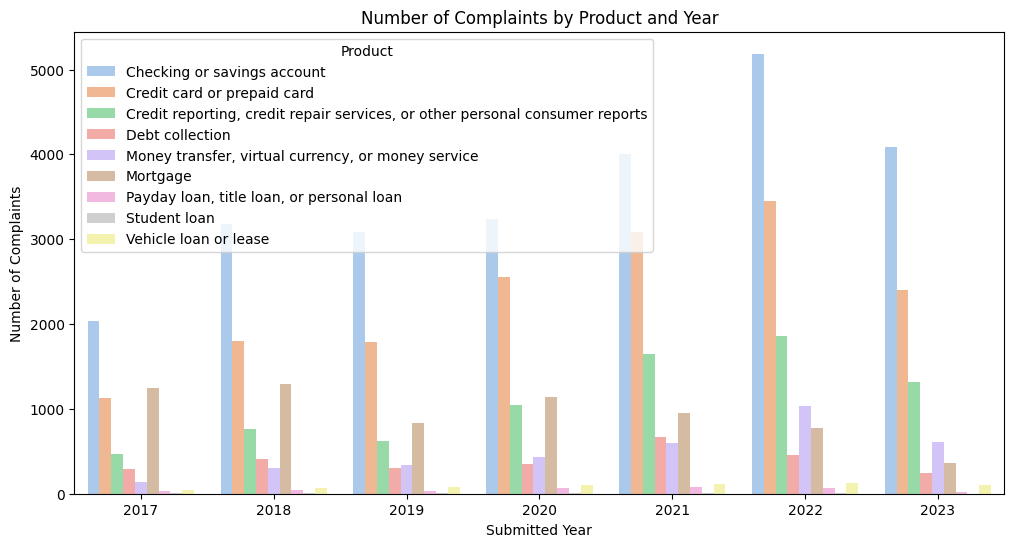

In [83]:
# complaints for each product change over time
plt.figure(figsize=(12,6))
sn.barplot(data=product_year_counts,x='Submitted Year',y='Count',hue='Product',palette='pastel')
plt.title("Number of Complaints by Product and Year")
plt.xlabel("Submitted Year")
plt.ylabel("Number of Complaints")
plt.legend(title="Product")
plt.show()

## **Issues ans Sub Issues**


In [84]:
# number of complaints for each Sub-issue within every Issue

pd.set_option('display.max_rows', None)
sub_issue_counts = data.groupby('Issue')['Sub-issue'].value_counts()
sub_issue_counts

Issue                                                                             Sub-issue                                                                            
Advertising                                                                       Confusing or misleading advertising about the card                                         10
                                                                                  Changes in terms from what was offered or advertised                                        4
Advertising and marketing, including promotional offers                           Didn't receive advertised or promotional terms                                            292
                                                                                  Confusing or misleading advertising about the credit card                                 195
Applying for a mortgage or refinancing an existing mortgage                       Not specified                                                                            1017
Attempts to collect debt not owed                                                 Debt is not yours                                                                         530
                                                                                  Debt was result of identity theft                                                         509
                                                                                  Debt was paid                                                                             210
                                                                                  Debt was already discharged in bankruptcy and is no longer owed                           102
Can't contact lender or servicer                                                  Not specified                                                                               8
Can't stop withdrawals from your bank account                                     Not specified                                                                               2
Charged fees or interest you didn't expect                                        Not specified                                                                              44
Closing an account                                                                Company closed your account                                                              1472
                                                                                  Funds not received from closed account                                                    852
                                                                                  Can't close your account                                                                  540
                                                                                  Fees charged for closing account                                                           89
Closing on a mortgage                                                             Closing disclosure or other related disclosures                                           610
Closing your account                                                              Company closed your account                                                               840
                                                                                  Can't close your account                                                                  237
Communication tactics                                                             Frequent or repeated calls                                                                106
                                                                                  You told them to stop contacting you, but they keep trying                                 49
                                                                                  Used obscene, profane, or other abusive language      

In [85]:
# issues are associated with each product
product_issue_counts = data.groupby(['Product', 'Issue']).size()
product_issue_counts

Product                                                                       Issue                                                                           
Checking or savings account                                                   Closing an account                                                                   2953
                                                                              Credit monitoring or identity theft protection services                                17
                                                                              Improper use of your report                                                            16
                                                                              Incorrect information on your report                                                  129
                                                                              Managing an account                                                                 15109
                                                                              Opening an account                                                                   2725
                                                                              Problem caused by your funds being low                                               1330
                                                                              Problem with a credit reporting company's investigation into an existing problem       20
                                                                              Problem with a lender or other company charging your account                         2493
                                                                              Problem with fraud alerts or security freezes                                          17
                                                                              Unable to get your credit report or credit score                                        5
Credit card or prepaid card                                                   Advertising                                                                            14
                                                                              Advertising and marketing, including promotional offers                               487
                                                                              Closing your account                                                                 1077
                                                                              Credit monitoring or identity theft protection services                                21
                                                                              Fees or interest                                                                     1422
                                                                              Getting a credit card                                                                1867
                                                                              Improper use of your report                                                            70
                                                                              Incorrect information on your report                                                  411
                                                                              Other features, terms, or problems                                                   1633
                                                                              Problem getting a card or closing an account                                          436
                                                                              Problem when making payments                                                         1328
                                                                              Problem with a credit reporting company's investigation into an exi

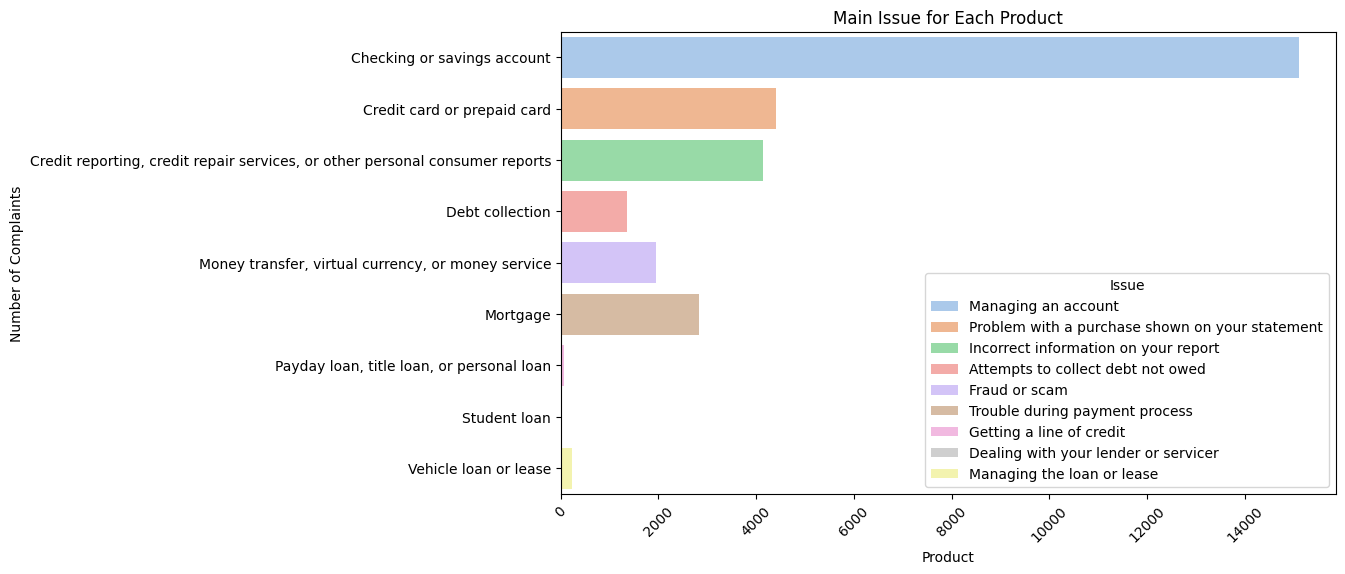

In [86]:
# the primary issue for each product
product_issue_counts = data.groupby(['Product', 'Issue']).size().reset_index(name='Count')
main_issue_per_product = product_issue_counts.loc[product_issue_counts.groupby('Product')['Count'].idxmax()]


plt.figure(figsize=(10,6))
sn.barplot(data=main_issue_per_product, x='Count', y='Product', hue='Issue', palette='pastel')

plt.title("Main Issue for Each Product")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

## **Responses**

In [87]:
# Count Timely Responses per Submission Channel
response_by_channel = data.groupby(['Submitted via', 'Timely response?']).size().reset_index(name='Count')
response_by_channel

,Submitted via,Timely response?,Count
0,Email,Yes,2
1,Fax,No,1
2,Fax,Yes,232
3,Phone,No,172
4,Phone,No response recorded,132
5,Phone,Yes,4380
6,Postal mail,No,28
7,Postal mail,No response recorded,8
8,Postal mail,Yes,1282
9,Referral,No,281


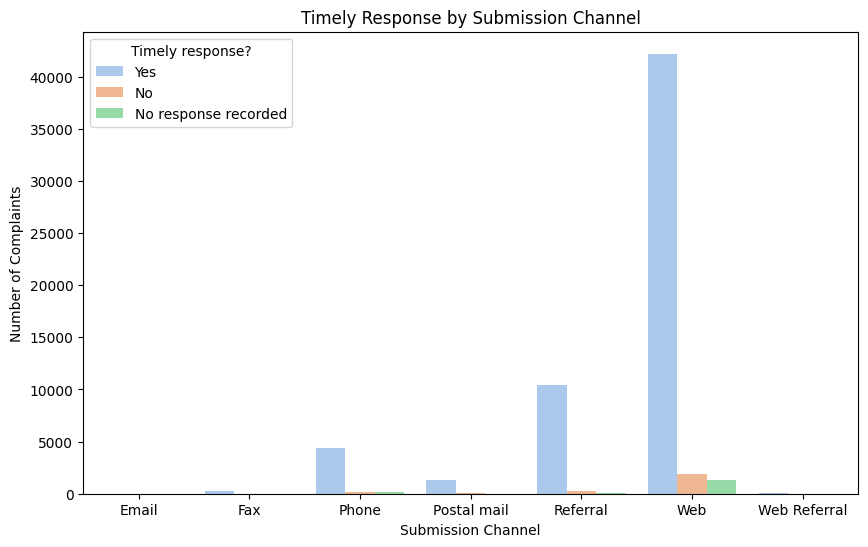

In [88]:
plt.figure(figsize=(10,6))
sn.barplot(
    data=response_by_channel,
    x='Submitted via',
    y='Count',
    hue='Timely response?',
    palette='pastel'
)

plt.title("Timely Response by Submission Channel")
plt.xlabel("Submission Channel")
plt.ylabel("Number of Complaints")
plt.show()

In [89]:
# Count Timely Response per Year
response_by_year = data.groupby(['Submitted Year', 'Timely response?']).size().reset_index(name='Count')
response_by_year

,Submitted Year,Timely response?,Count
0,2017,No,9
1,2017,Yes,5385
2,2018,No,12
3,2018,Yes,7860
4,2019,No,7
5,2019,Yes,7068
6,2020,No,62
7,2020,Yes,8880
8,2021,No,1224
9,2021,Yes,9925


In [90]:
fig = px.bar(response_by_year, x='Submitted Year', y='Count', color='Timely response?',
title='Timely Response by Year',text='Count',color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_traces(textposition='outside')
fig.show()

In [91]:
# percentage of complaints were handled on time
data['Timely response?'].value_counts(normalize=True) * 100

,proportion
Timely response?,
Yes,93.766396
No,3.843816
No response recorded,2.389788


In [92]:
# common type of public response from companies
data['Company public response'].value_counts()

,count
Company public response,
Company has responded to the consumer and the CFPB and chooses not to provide a public response,62486
Company believes the complaint provided an opportunity to answer consumer's questions,12
Company believes the complaint is the result of a misunderstanding,7
Company believes it acted appropriately as authorized by contract or law,6
Company believes complaint caused principally by actions of third party outside the control or direction of the company,3
Company disputes the facts presented in the complaint,2


In [93]:
# most common resolution type
data['Company response to consumer'].value_counts()

,count
Company response to consumer,
Closed with explanation,41044
Closed with monetary relief,14697
Closed with non-monetary relief,5273
In progress,1494
Closed,8


<Axes: xlabel='Timely response?', ylabel='Company response to consumer'>

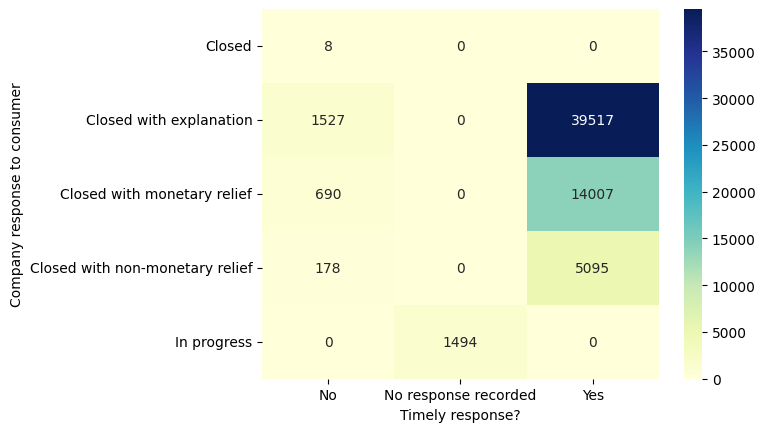

In [94]:
pivot = pd.crosstab(
    data['Company response to consumer'],
    data['Timely response?']
)

sn.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')

In [95]:
data.to_csv('Complaints Analysis.csv', index=False)

# **Predicting whether a complaint will receive a timely response**

### **Prepare Data**

In [96]:
dt = data.copy()

In [97]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62516 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     62516 non-null  object        
 9   Company public response       62516 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

In [98]:
dt['Submit_Month'] = dt['Date submitted'].dt.month
dt['Submit_Day'] = dt['Date submitted'].dt.day
dt['Submit_Weekday'] = dt['Date submitted'].dt.dayofweek
dt['Receive_Month'] = dt['Date received'].dt.month
dt['Receive_Day'] = dt['Date received'].dt.day
dt = dt.drop(columns=['Date submitted','Date received'])

In [99]:
x = dt.drop(['Timely response?','Complaint ID'],axis = 1 )
y = dt['Timely response?']

In [100]:
x.shape

(62516, 17)

In [101]:
y.shape

(62516,)

In [102]:
x.head()

,Submitted via,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,State name,Received Year,Submitted Year,Days_to_receive,Submit_Month,Submit_Day,Submit_Weekday,Receive_Month,Receive_Day
0,Referral,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,Not specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,New York,2021,2021,3,10,24,6,10,27
1,Web,FL,"Money transfer, virtual currency, or money service",Refund anticipation check,Lost or stolen check,Not specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Florida,2020,2020,0,4,24,4,4,24
2,Web,CA,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,California,2022,2022,0,7,27,2,7,27
3,Referral,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a card",Company has responded to the consumer and the CFPB and chooses not to provide a public response,In progress,California,2023,2023,1,7,10,0,7,11
4,Referral,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Virginia,2022,2022,1,7,27,2,7,28


In [103]:
y.head()

,Timely response?
0,Yes
1,Yes
2,Yes
3,No response recorded
4,Yes


### **Encode Categorical Data**

In [104]:
x = pd.get_dummies(x)
le = LabelEncoder()
y = le.fit_transform(y)

In [105]:
x.shape

(62516, 419)

In [106]:
x.head()

,Received Year,Submitted Year,Days_to_receive,Submit_Month,Submit_Day,Submit_Weekday,Receive_Month,Receive_Day,Submitted via_Email,Submitted via_Fax,...,State name_South Dakota,State name_Tennessee,State name_Texas,State name_Utah,State name_Vermont,State name_Virginia,State name_Washington,State name_West Virginia,State name_Wisconsin,State name_Wyoming
0,2021,2021,3,10,24,6,10,27,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2020,2020,0,4,24,4,4,24,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2022,2022,0,7,27,2,7,27,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2023,2023,1,7,10,0,7,11,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2022,2022,1,7,27,2,7,28,False,False,...,False,False,False,False,False,True,False,False,False,False


In [107]:
y.shape

(62516,)

### **Train Test Split**

In [108]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### **Train Model**

In [109]:
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

### **Evaluate Model**

In [110]:
y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9642514395393474
              precision    recall  f1-score   support

           0       0.77      0.12      0.21       490
           1       1.00      1.00      1.00       297
           2       0.96      1.00      0.98     11717

    accuracy                           0.96     12504
   macro avg       0.91      0.71      0.73     12504
weighted avg       0.96      0.96      0.95     12504



# **The impossible is possible**